In [1]:
import os

# First, mount drive if not already done
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import os

In [15]:
raw_path = "/content/drive/MyDrive/MutualFundAnalytics/Data/Raw"

processed_path = "/content/drive/MyDrive/MutualFundAnalytics/Data/Processed"

In [16]:
for file in os.listdir(raw_path):
    print(file)

Copy of 06_industry_folio_count.csv
Copy of 08_investor_transactions.csv
Copy of 07_scheme_performance.csv
Copy of 10_benchmark_indices.csv
Copy of 01_fund_master.csv
Copy of 03_aum_by_fund_house.csv
Copy of 02_nav_history.csv
Copy of 05_category_inflows.csv
Copy of 09_portfolio_holdings.csv
Copy of 04_monthly_sip_inflows.csv
HDFC_TOP100_NAV.csv
SBI_Bluechip.csv
ICICI_Bluechip.csv
Nippon_LargeCap.csv
Axis_Bluechip.csv
Kotak_Bluechip.csv


In [17]:
fund_master = pd.read_csv(f"{raw_path}/Copy of 01_fund_master.csv")

nav_history = pd.read_csv(f"{raw_path}/Copy of 02_nav_history.csv")

aum = pd.read_csv(f"{raw_path}/Copy of 03_aum_by_fund_house.csv")

sip = pd.read_csv(f"{raw_path}/Copy of 04_monthly_sip_inflows.csv")

category = pd.read_csv(f"{raw_path}/Copy of 05_category_inflows.csv")

folio = pd.read_csv(f"{raw_path}/Copy of 06_industry_folio_count.csv")

performance = pd.read_csv(f"{raw_path}/Copy of 07_scheme_performance.csv")

transactions = pd.read_csv(f"{raw_path}/Copy of 08_investor_transactions.csv")

holdings = pd.read_csv(f"{raw_path}/Copy of 09_portfolio_holdings.csv")

benchmark = pd.read_csv(f"{raw_path}/Copy of 10_benchmark_indices.csv")

In [18]:
datasets = {
    "fund_master": fund_master,
    "nav_history": nav_history,
    "aum": aum,
    "sip": sip,
    "category": category,
    "folio": folio,
    "performance": performance,
    "transactions": transactions,
    "holdings": holdings,
    "benchmark": benchmark
}

for name, df in datasets.items():

    print("\n")
    print("="*60)

    print(name)

    print("="*60)

    print(df.columns.tolist())

    print("\nShape:", df.shape)



fund_master
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

Shape: (40, 15)


nav_history
['amfi_code', 'date', 'nav']

Shape: (46000, 3)


aum
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

Shape: (90, 5)


sip
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Shape: (48, 6)


category
['month', 'category', 'net_inflow_crore']

Shape: (144, 3)


folio
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

Shape: (21, 6)


performance
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann

In [19]:
transactions.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

In [20]:
aum.columns.tolist()

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

In [21]:
sip.columns.tolist()

['month',
 'sip_inflow_crore',
 'active_sip_accounts_crore',
 'new_sip_accounts_lakh',
 'sip_aum_lakh_crore',
 'yoy_growth_pct']

In [22]:
category.columns.tolist()

['month', 'category', 'net_inflow_crore']

In [23]:
folio.columns.tolist()

['month',
 'total_folios_crore',
 'equity_folios_crore',
 'debt_folios_crore',
 'hybrid_folios_crore',
 'others_folios_crore']

In [24]:
holdings.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

In [25]:
nav.dtypes

,0
amfi_code,int64
date,datetime64[ns]
nav,float64


In [26]:
nav['amfi_code'].nunique()

40

In [28]:
# Merge nav with scheme names
nav_merged = nav.merge(
    performance[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code',
    how='left'
)

# Plot with plotly
fig = px.line(
    nav_merged,
    x='date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trends 2022–2026 (All 40 Schemes)',
    labels={'nav': 'NAV (₹)', 'date': 'Date'},
    height=600
)

# Highlight 2023 bull run
fig.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="green", opacity=0.1,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 correction
fig.add_vrect(
    x0="2024-06-01", x1="2024-10-31",
    fillcolor="red", opacity=0.1,
    annotation_text="2024 Correction",
    annotation_position="top left"
)

fig.update_layout(
    showlegend=False,
    xaxis_title="Date",
    yaxis_title="NAV (₹)"
)

# Save using matplotlib instead
fig.write_html(f"{charts_path}/chart1_nav_trends.html")
fig.show()
print("✅ Chart 1 saved as HTML!")

✅ Chart 1 saved as HTML!


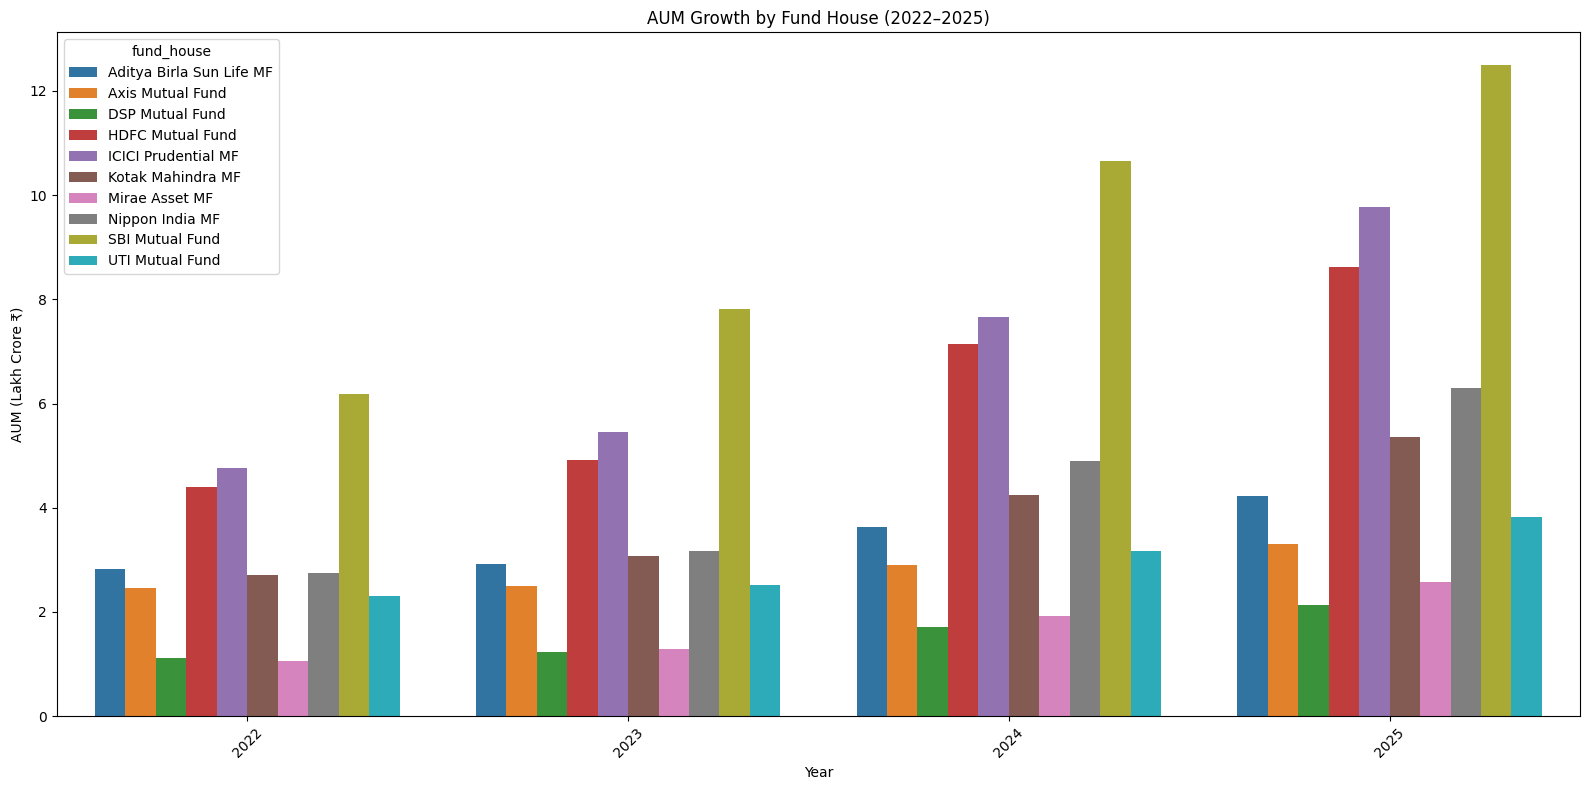

✅ Chart 2 saved!


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert date column
aum['date'] = pd.to_datetime(aum['date'])

# Extract year
aum['year'] = aum['date'].dt.year

# Aggregate AUM by fund house and year
aum_yearly = (
    aum.groupby(['year', 'fund_house'])['aum_lakh_crore']
    .mean()
    .reset_index()
)

plt.figure(figsize=(16,8))

sns.barplot(
    data=aum_yearly,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title('AUM Growth by Fund House (2022–2025)')
plt.xlabel('Year')
plt.ylabel('AUM (Lakh Crore ₹)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(f"{charts_path}/chart2_aum_growth.png")

plt.show()

print("✅ Chart 2 saved!")

In [30]:
sip['month'] = pd.to_datetime(sip['month'])

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (2022–2025)',
    markers=True
)

# Find highest SIP inflow
max_row = sip.loc[sip['sip_inflow_crore'].idxmax()]

fig.add_annotation(
    x=max_row['month'],
    y=max_row['sip_inflow_crore'],
    text=f"All-Time High: ₹{max_row['sip_inflow_crore']:.0f} Cr",
    showarrow=True
)

fig.write_html(
    f"{charts_path}/chart3_sip_trend.html"
)

fig.show()

print("✅ Chart 3 saved!")

✅ Chart 3 saved!


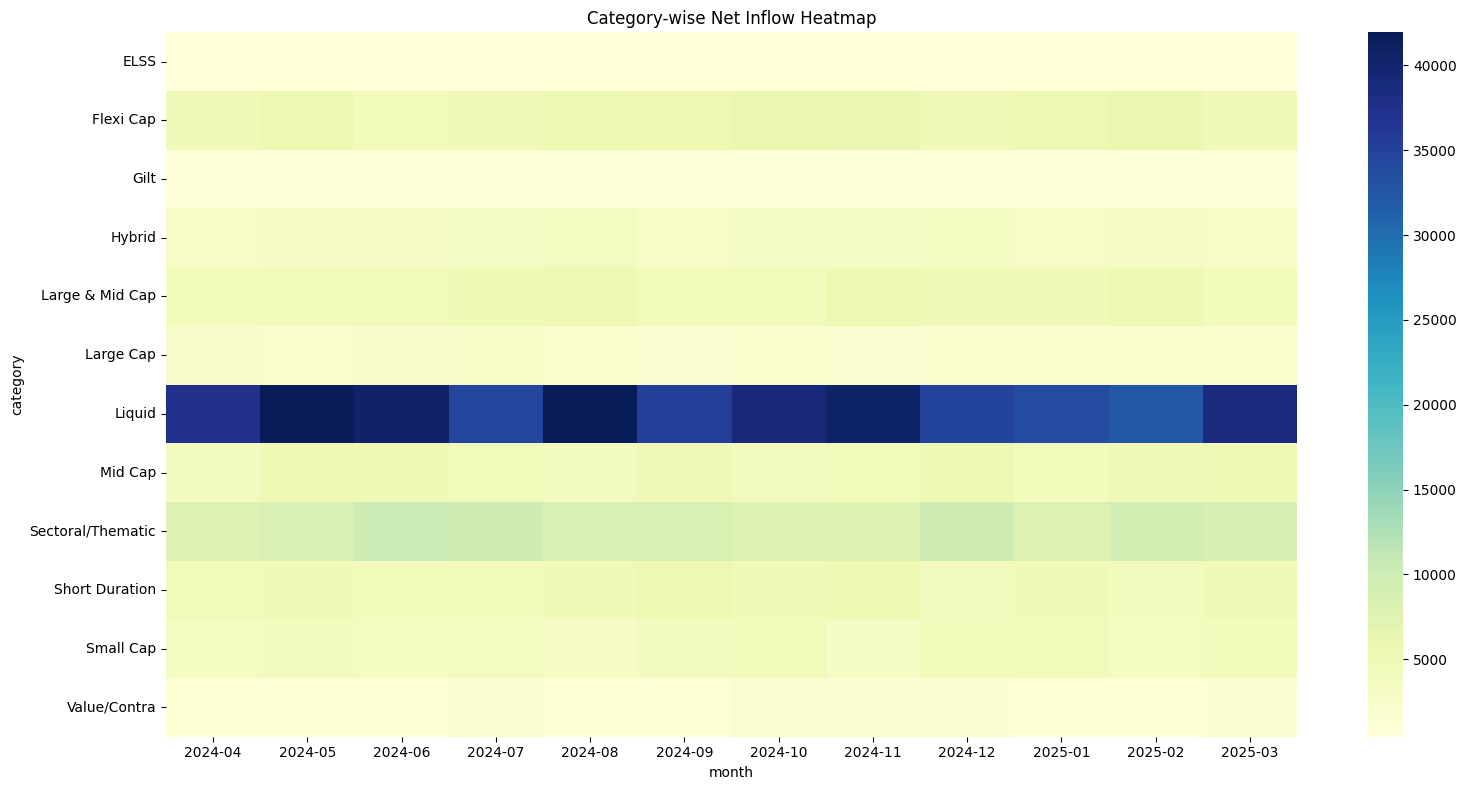

✅ Chart 4 saved!


In [31]:
pivot_table = category.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore',
    aggfunc='sum'
)

plt.figure(figsize=(16,8))

sns.heatmap(
    pivot_table,
    cmap='YlGnBu'
)

plt.title('Category-wise Net Inflow Heatmap')

plt.tight_layout()

plt.savefig(
    f"{charts_path}/chart4_category_heatmap.png"
)

plt.show()

print("✅ Chart 4 saved!")

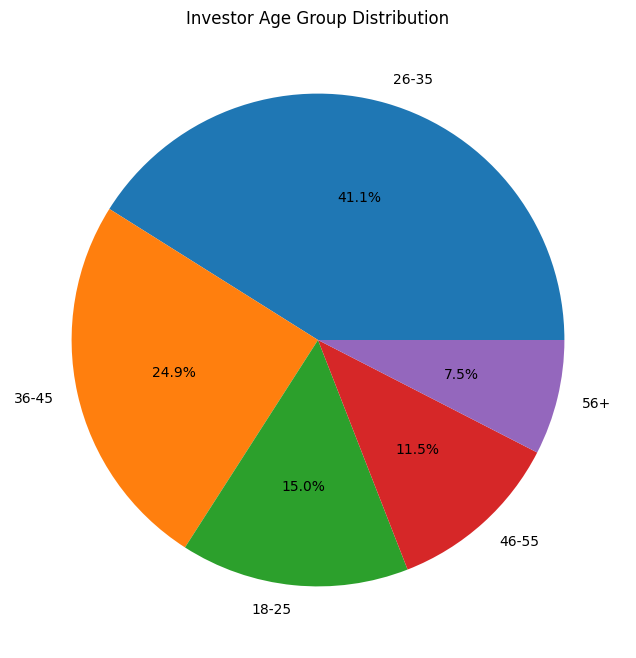

✅ Chart 5 saved!


In [32]:
age_counts = transactions['age_group'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%'
)

plt.title(
    'Investor Age Group Distribution'
)

plt.savefig(
    f"{charts_path}/chart5_age_distribution.png"
)

plt.show()

print("✅ Chart 5 saved!")

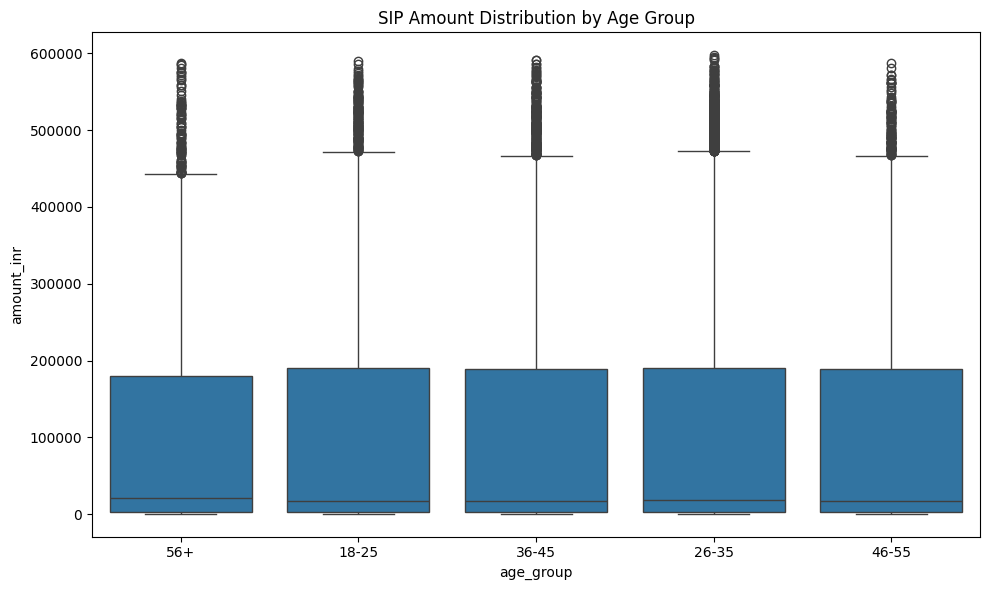

✅ Chart 6 saved!


In [33]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x='age_group',
    y='amount_inr'
)

plt.title(
    'SIP Amount Distribution by Age Group'
)

plt.tight_layout()

plt.savefig(
    f"{charts_path}/chart6_sip_boxplot.png"
)

plt.show()

print("✅ Chart 6 saved!")

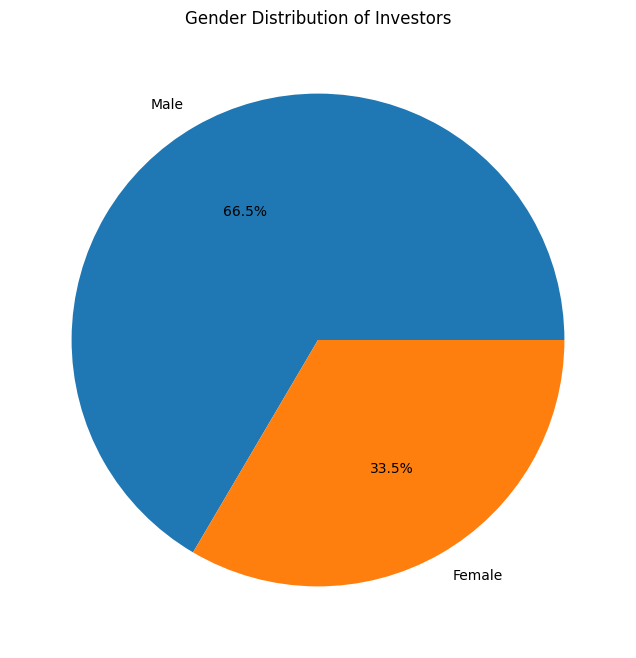

In [34]:
gender_counts = transactions['gender'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title('Gender Distribution of Investors')

plt.savefig(f"{charts_path}/chart7_gender_split.png")

plt.show()

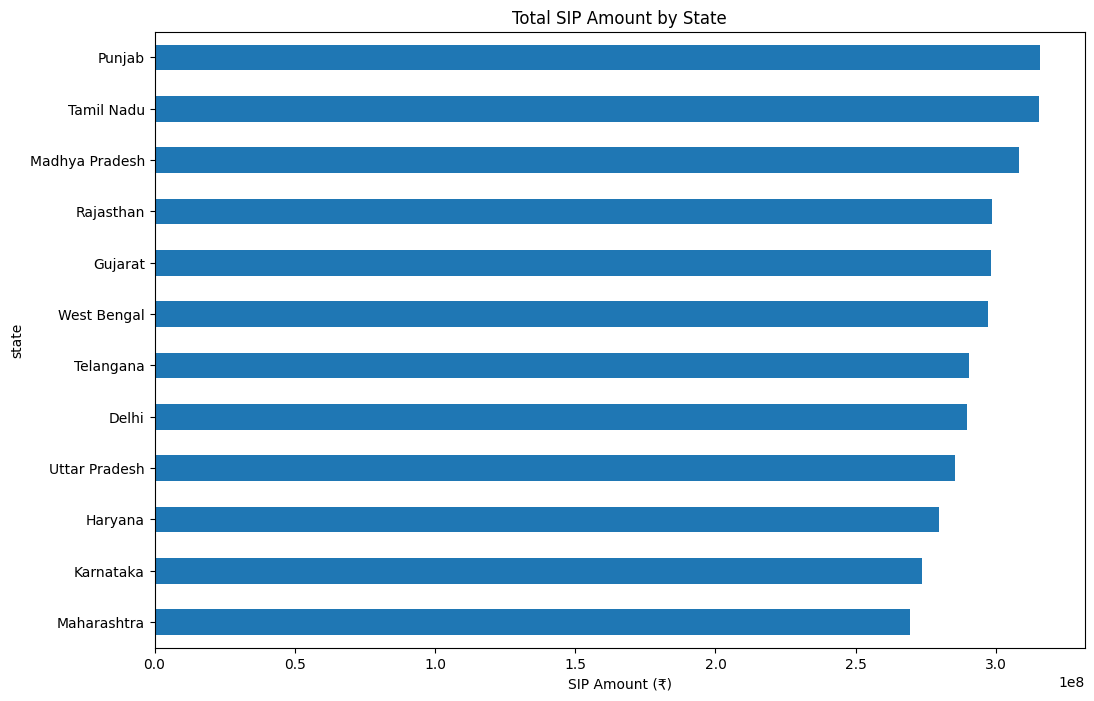

In [35]:
state_sip = (
    transactions.groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,8))

state_sip.plot(kind='barh')

plt.title('Total SIP Amount by State')

plt.xlabel('SIP Amount (₹)')

plt.savefig(f"{charts_path}/chart8_state_sip.png")

plt.show()

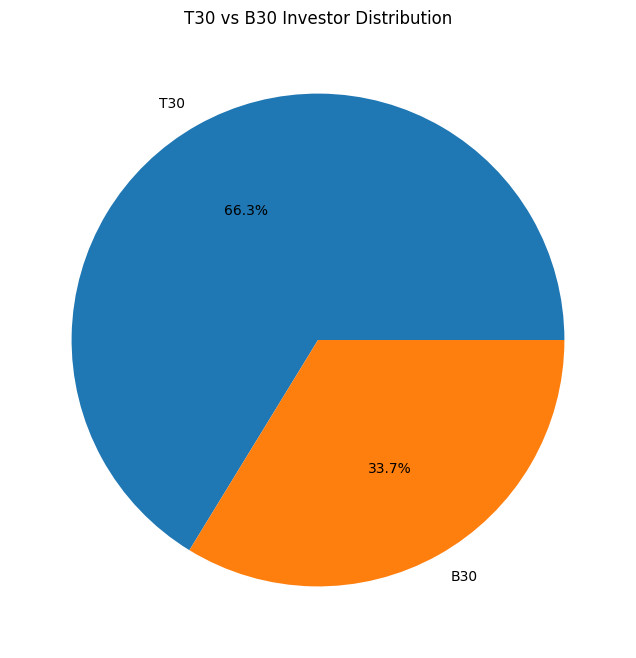

In [36]:
city_counts = transactions['city_tier'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct='%1.1f%%'
)

plt.title('T30 vs B30 Investor Distribution')

plt.savefig(f"{charts_path}/chart9_t30_b30.png")

plt.show()

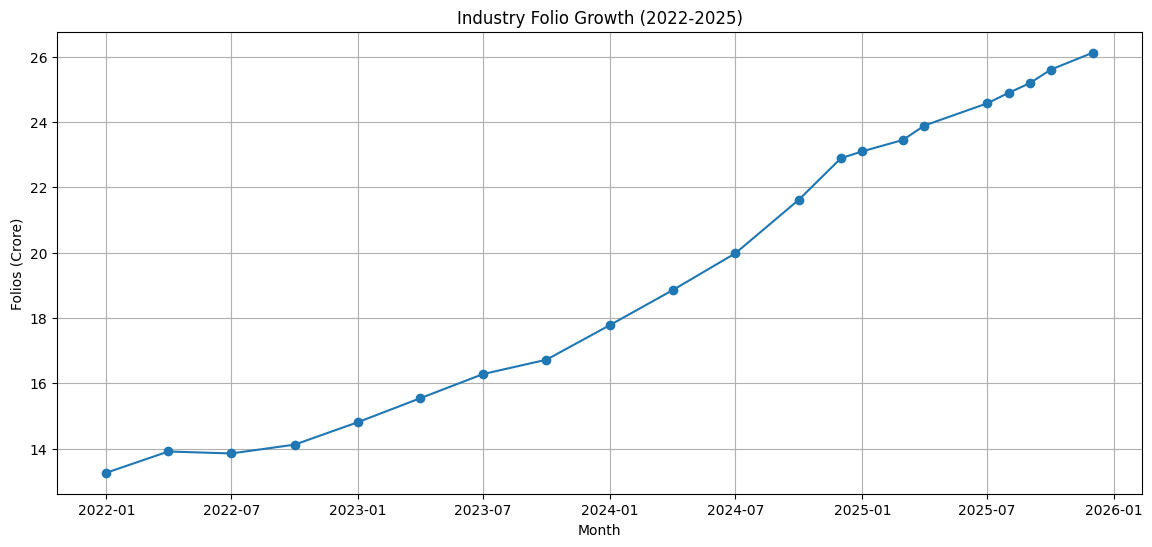

In [37]:
folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(14,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o'
)

plt.title('Industry Folio Growth (2022-2025)')

plt.xlabel('Month')

plt.ylabel('Folios (Crore)')

plt.grid()

plt.savefig(f"{charts_path}/chart10_folio_growth.png")

plt.show()

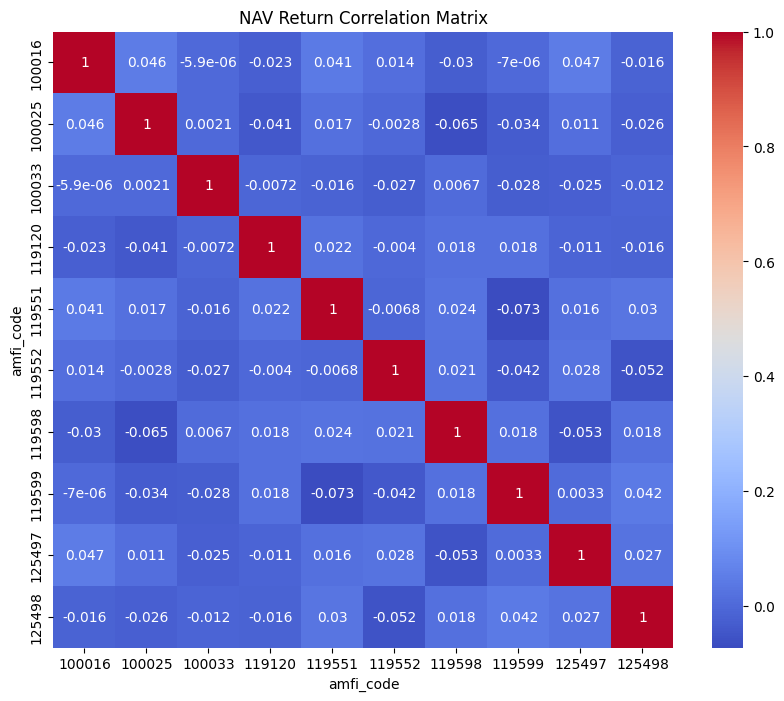

In [38]:
selected_funds = (
    nav['amfi_code']
    .drop_duplicates()
    .head(10)
)

nav_10 = nav[
    nav['amfi_code'].isin(selected_funds)
]

pivot = nav_10.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('NAV Return Correlation Matrix')

plt.savefig(f"{charts_path}/chart11_correlation_matrix.png")

plt.show()

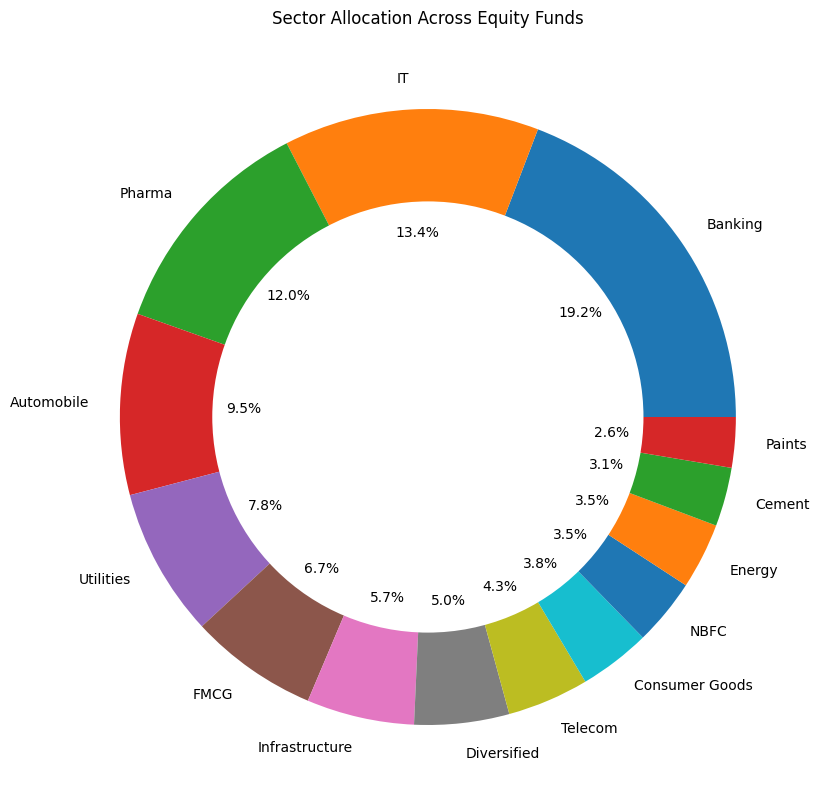

In [39]:
sector_weights = (
    holdings.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

fig = plt.gcf()

fig.gca().add_artist(centre_circle)

plt.title('Sector Allocation Across Equity Funds')

plt.savefig(f"{charts_path}/chart12_sector_donut.png")

plt.show()

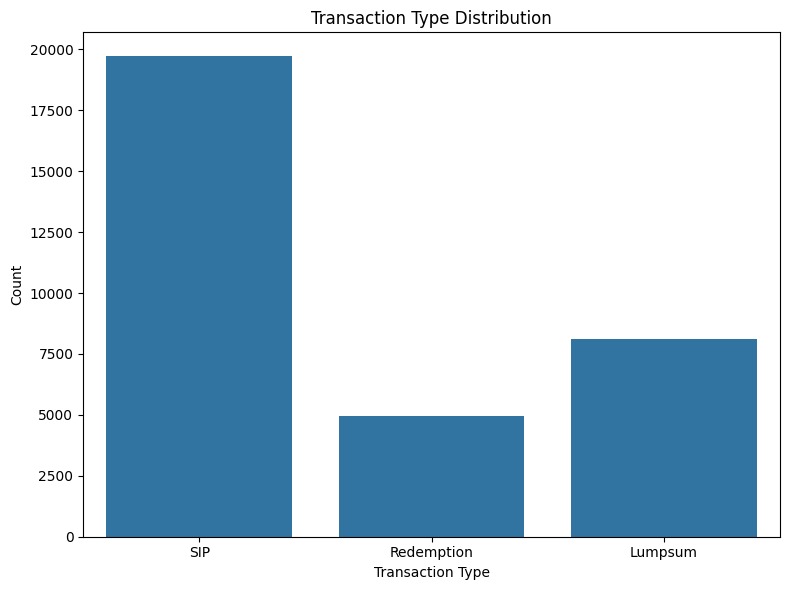

✅ Chart 13 saved!


In [40]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=transactions,
    x='transaction_type'
)

plt.title('Transaction Type Distribution')

plt.xlabel('Transaction Type')
plt.ylabel('Count')

plt.tight_layout()

plt.savefig(
    f"{charts_path}/chart13_transaction_type.png"
)

plt.show()

print("✅ Chart 13 saved!")

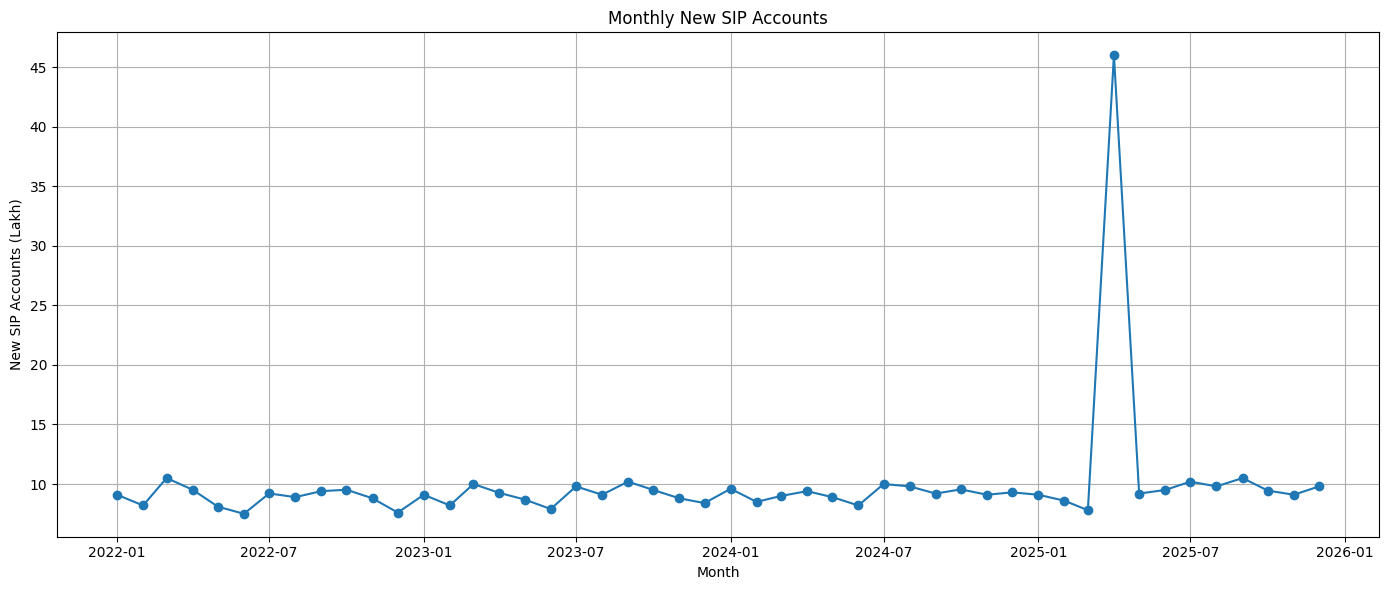

✅ Chart 14 saved!


In [41]:
sip['month'] = pd.to_datetime(sip['month'])

plt.figure(figsize=(14,6))

plt.plot(
    sip['month'],
    sip['new_sip_accounts_lakh'],
    marker='o'
)

plt.title('Monthly New SIP Accounts')

plt.xlabel('Month')
plt.ylabel('New SIP Accounts (Lakh)')

plt.grid()

plt.tight_layout()

plt.savefig(
    f"{charts_path}/chart14_new_sip_accounts.png"
)

plt.show()

print("✅ Chart 14 saved!")

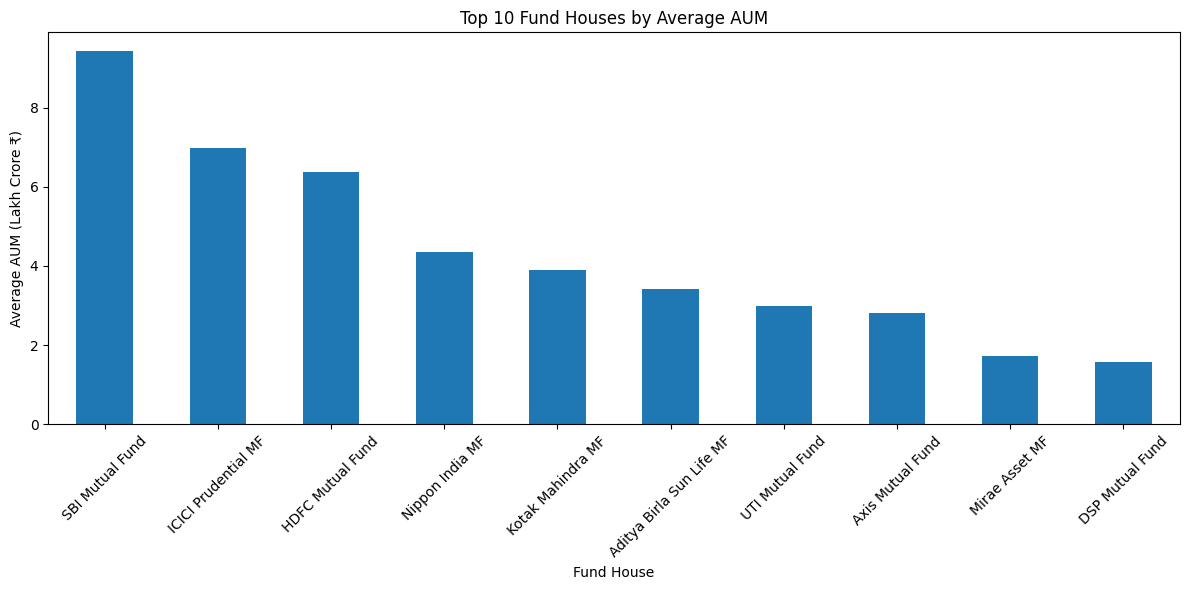

✅ Chart 15 saved!


In [42]:
top_aum = (
    aum.groupby('fund_house')['aum_lakh_crore']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_aum.plot(kind='bar')

plt.title('Top 10 Fund Houses by Average AUM')

plt.xlabel('Fund House')
plt.ylabel('Average AUM (Lakh Crore ₹)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    f"{charts_path}/chart15_top_fund_houses.png"
)

plt.show()

print("✅ Chart 15 saved!")

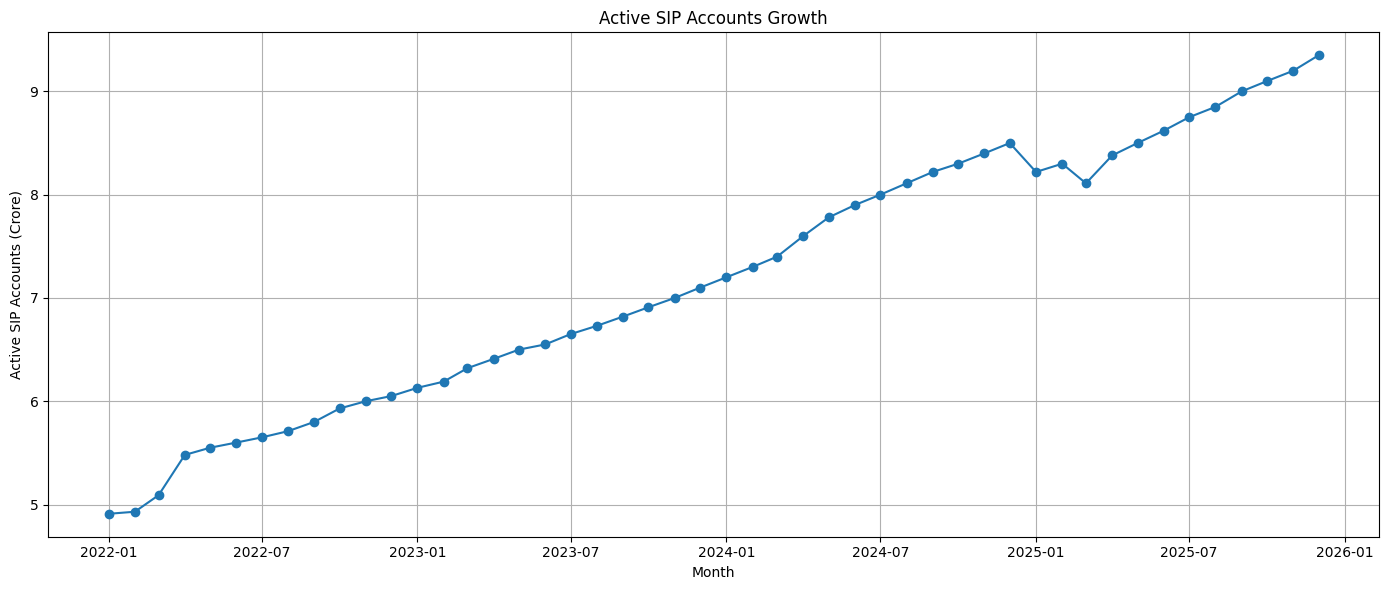

✅ Chart 16 saved!


In [43]:
plt.figure(figsize=(14,6))

plt.plot(
    sip['month'],
    sip['active_sip_accounts_crore'],
    marker='o'
)

plt.title('Active SIP Accounts Growth')

plt.xlabel('Month')
plt.ylabel('Active SIP Accounts (Crore)')

plt.grid()

plt.tight_layout()

plt.savefig(
    f"{charts_path}/chart16_active_sip_accounts.png"
)

plt.show()

print("✅ Chart 16 saved!")

Finding 1:
SBI Mutual Fund maintained the highest average AUM among all fund houses (Refer: Chart 2 & Chart 15).

Finding 2:
Monthly SIP inflows reached an all-time high of ₹31,002 crore in December 2025 (Refer: Chart 3).

Finding 3:
Equity-oriented categories consistently attracted higher inflows than debt and hybrid categories (Refer: Chart 4).

Finding 4:
Investors aged 25–40 form the largest segment of mutual fund participants (Refer: Chart 5).

Finding 5:
Middle-aged investors contribute larger SIP amounts compared to other age groups (Refer: Chart 6).

Finding 6:
T30 cities account for the majority of mutual fund investments (Refer: Chart 9).

Finding 7:
Industry folio count nearly doubled between 2022 and 2025 (Refer: Chart 10).

Finding 8:
Most large-cap mutual funds exhibit strong positive return correlations (Refer: Chart 11).

Finding 9:
Financial Services and IT sectors dominate portfolio allocations across equity funds (Refer: Chart 12).

Finding 10:
SIP transactions are significantly more common than redemption transactions (Refer: Chart 13).

